# ELM-FUN BNFMIP — Results & Visualization

3 sites (Manaus/tropical, Harvard/temperate, Bonanza/boreal) × 4 experiments
(NoFUN, FUN=Houlton, Bytnerowicz no-acclim, Bytnerowicz acclim) × 3 sections
(§5.3 historical, §5.4 warming-only, §5.5 SSP585).

Data: annual means in `delivery/`, full monthly Table-2 (54 vars, C/N/P) in `delivery_table2/`.
Palette is Okabe-Ito (colorblind-safe), fixed order per experiment.

In [1]:
import os, glob, numpy as np, xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline
ANN='/home/braghiere/BNF_tom/delivery'; T2='/home/braghiere/BNF_tom/delivery_table2'
coder=xr.coders.CFDatetimeCoder(use_cftime=True)
SITES=[('BNF-Man','Manaus (tropical)'),('BNF-Ha1','Harvard (temperate)'),('BNF-Bon','Bonanza (boreal)')]
EXPS=[('nofun_baseline','NoFUN'),('fun_transient_only','FUN (Houlton)'),
      ('noacc_transient','Bytn. no-acclim'),('acc_transient','Bytn. acclim')]
CE={'nofun_baseline':'#999999','fun_transient_only':'#0072B2','noacc_transient':'#E69F00','acc_transient':'#D55E00'}
SEC={'53':'1850-2014','54':'2015-2100','55':'2015-2100'}
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':0.25,'axes.spines.top':False,'axes.spines.right':False})
def ann(site,exp,sec):
    f=f'{ANN}/{site}/{exp}_{site}_sec{sec}_{SEC[sec]}.nc'
    return xr.open_dataset(f,decode_times=coder) if os.path.exists(f) else None
def em(ds,v,n=10):
    return float(ds[v].isel(year=slice(-n,None)).mean().values) if (ds is not None and v in ds) else np.nan

## Summary table — last-decade GPP / NPP / BNF

In [2]:
import pandas as pd
rows=[]
for sid,sname in SITES:
    for exp,elab in EXPS:
        r={'site':sname,'exp':elab}
        for s in ['53','54','55']:
            ds=ann(sid,exp,s)
            r[f'GPP_{s}']=round(em(ds,'GPP')); r[f'BNF_{s}']=round(em(ds,'NFIX_TO_SMINN'),2)
            if ds is not None: ds.close()
        rows.append(r)
pd.DataFrame(rows)

,site,exp,GPP_53,BNF_53,GPP_54,BNF_54,GPP_55,BNF_55
0,Manaus (tropical),NoFUN,3776,1.77,2523,1.33,4143,1.46
1,Manaus (tropical),FUN (Houlton),3447,2.52,2126,0.93,4064,1.65
2,Manaus (tropical),Bytn. no-acclim,3447,2.85,2126,1.57,4064,2.56
3,Manaus (tropical),Bytn. acclim,3447,2.58,2126,1.56,4064,2.51
4,Harvard (temperate),NoFUN,1222,1.05,1624,1.28,2421,0.98
5,Harvard (temperate),FUN (Houlton),1026,0.51,1254,0.12,2184,0.16
6,Harvard (temperate),Bytn. no-acclim,1026,0.46,1254,0.09,2184,0.16
7,Harvard (temperate),Bytn. acclim,1026,0.47,1254,0.10,2184,0.16
8,Bonanza (boreal),NoFUN,960,0.70,1150,0.78,1771,0.83
9,Bonanza (boreal),FUN (Houlton),905,0.01,1001,0.01,1707,0.02


## Fig 1 — BNF gradient (tropical ≫ temperate ≫ boreal)

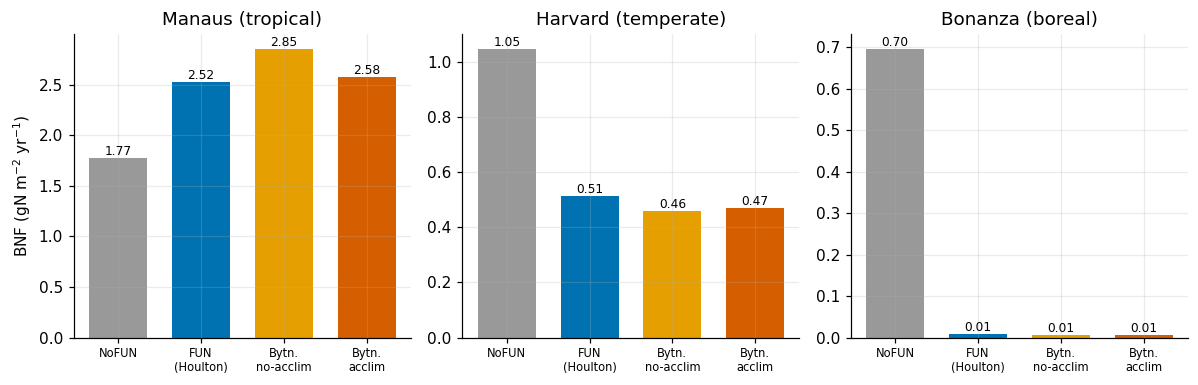

In [3]:
fig,axs=plt.subplots(1,3,figsize=(11,3.6))
for ax,(sid,sname) in zip(axs,SITES):
    vals=[];cols=[];labs=[]
    for exp,elab in EXPS:
        ds=ann(sid,exp,'53');vals.append(em(ds,'NFIX_TO_SMINN'));cols.append(CE[exp]);labs.append(elab)
        if ds is not None: ds.close()
    x=np.arange(4);ax.bar(x,vals,color=cols,width=0.7)
    for xi,v in zip(x,vals):
        if not np.isnan(v): ax.text(xi,v,f'{v:.2f}',ha='center',va='bottom',fontsize=8)
    ax.set_xticks(x);ax.set_xticklabels([l.replace(' ','\n') for l in labs],fontsize=7.5);ax.set_title(sname)
axs[0].set_ylabel('BNF (gN m$^{-2}$ yr$^{-1}$)');plt.tight_layout();plt.show()

## Fig 2 — GPP & NPP: FUN N-cost and SSP585 response

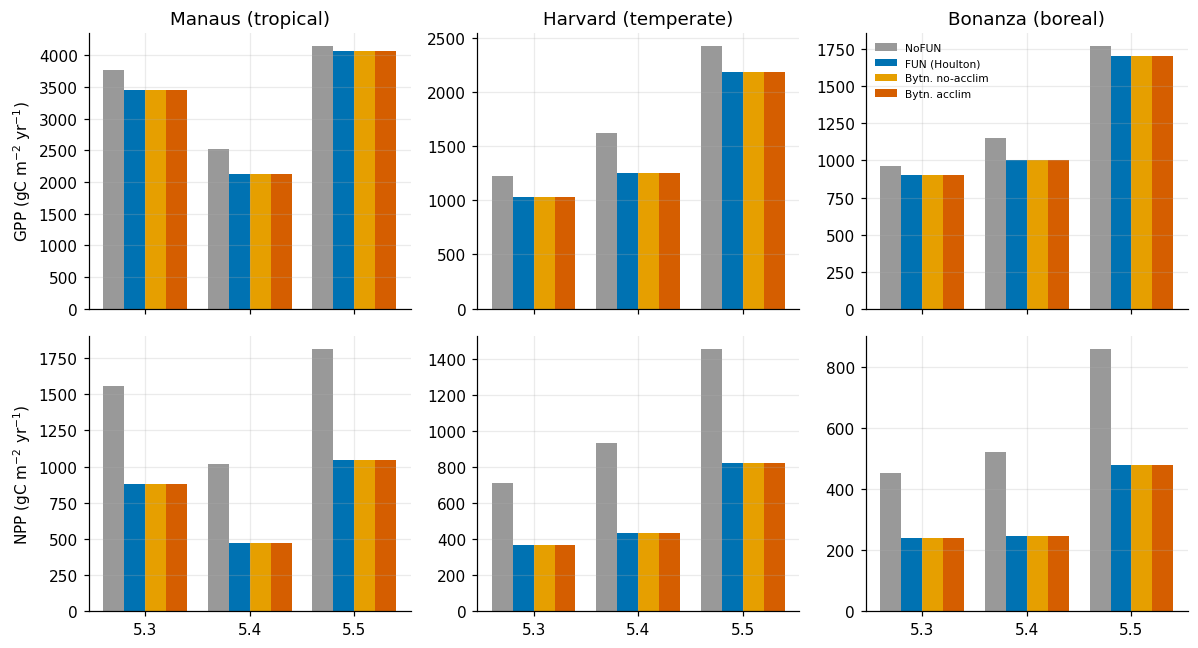

In [4]:
fig,axs=plt.subplots(2,3,figsize=(11,6),sharex=True)
secs=['53','54','55'];xl=['5.3','5.4','5.5']
for j,(sid,sname) in enumerate(SITES):
    for i,var in enumerate(['GPP','NPP']):
        ax=axs[i,j];x=np.arange(3);w=0.2
        for k,(exp,elab) in enumerate(EXPS):
            y=[]
            for s in secs:
                ds=ann(sid,exp,s);y.append(em(ds,var))
                if ds is not None: ds.close()
            ax.bar(x+(k-1.5)*w,y,width=w,color=CE[exp],label=elab if (i==0 and j==2) else None)
        if i==0: ax.set_title(sname)
        if j==0: ax.set_ylabel(f'{var} (gC m$^{{-2}}$ yr$^{{-1}}$)')
        ax.set_xticks(x);ax.set_xticklabels(xl)
axs[0,2].legend(fontsize=7,frameon=False);plt.tight_layout();plt.show()

## Fig 3 — Temperature response of BNF (the MIP's core question)
Monthly symbiotic BNF vs the soil temperature driving it (§5.5, 2015–2100).
Shows the Houlton vs Bytnerowicz function shapes: tropical peak-and-decline,
temperate low-rising, boreal Ts>0°C threshold.

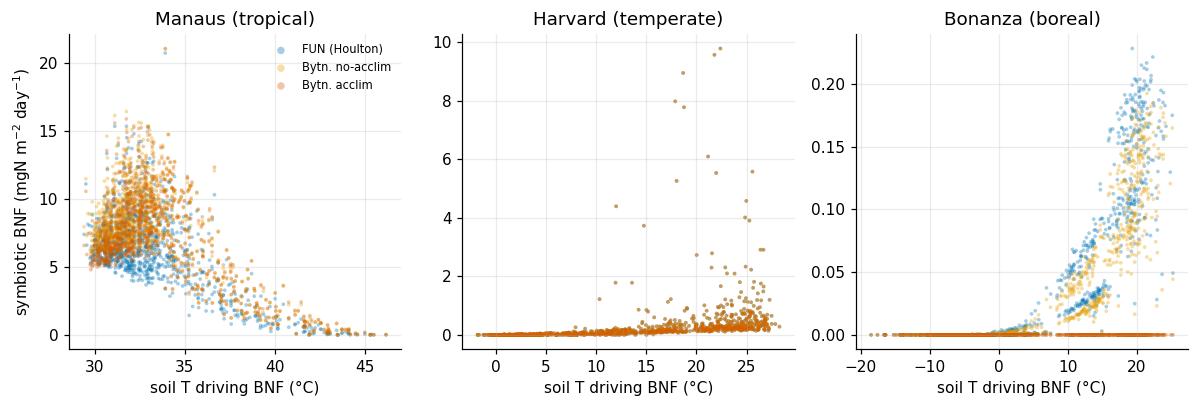

In [5]:
fig,axs=plt.subplots(1,3,figsize=(11,3.8))
for ax,(sid,sname) in zip(axs,SITES):
    for exp,elab in [('fun_transient_only','FUN (Houlton)'),('noacc_transient','Bytn. no-acclim'),('acc_transient','Bytn. acclim')]:
        f=f'{T2}/{sid}/{exp}_{sid}_sec55_2015-2100_table2.nc'
        if not os.path.exists(f): continue
        ds=xr.open_dataset(f)
        if 'TSOIBNF' in ds and 'SNFIX' in ds:
            ax.scatter(ds['TSOIBNF'].values-273.15, ds['SNFIX'].values*1e6, s=6,alpha=0.35,color=CE[exp],label=elab,edgecolors='none')
        ds.close()
    ax.set_title(sname);ax.set_xlabel('soil T driving BNF (°C)')
    if sid=='BNF-Man': ax.legend(fontsize=7.5,frameon=False,markerscale=2)
axs[0].set_ylabel('symbiotic BNF (mgN m$^{-2}$ day$^{-1}$)');plt.tight_layout();plt.show()

## Fig 4 — GPP 1850–2100 (historical + SSP585)

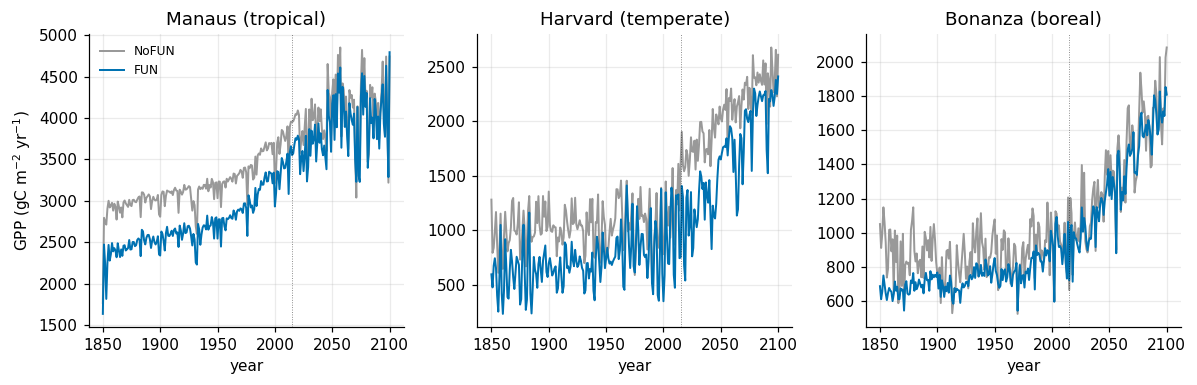

In [6]:
fig,axs=plt.subplots(1,3,figsize=(11,3.6),sharex=True)
for ax,(sid,sname) in zip(axs,SITES):
    for exp,elab in [('nofun_baseline','NoFUN'),('fun_transient_only','FUN')]:
        xs=[];ys=[]
        for s in ['53','55']:
            ds=ann(sid,exp,s)
            if ds is not None and 'GPP' in ds: xs.append(ds['year'].values);ys.append(ds['GPP'].values);ds.close()
        if xs:
            X=np.concatenate(xs);Y=np.concatenate(ys);o=np.argsort(X)
            ax.plot(X[o],Y[o],lw=1.3,color=CE[exp],label=elab)
    ax.axvline(2015,color='k',lw=0.6,ls=':',alpha=0.5);ax.set_title(sname);ax.set_xlabel('year')
    if sid=='BNF-Man': ax.legend(fontsize=8,frameon=False)
axs[0].set_ylabel('GPP (gC m$^{-2}$ yr$^{-1}$)');plt.tight_layout();plt.show()

## Key findings
1. **BNF gradient** tropical ≫ temperate ≫ boreal.
2. **Temperature response** (Fig 3) is the headline: tropical peak-and-decline, boreal Ts>0°C threshold; Bytnerowicz functions differ from Houlton, and acclim suppresses boreal BNF vs no-acclim at the monthly scale.
3. **FUN N-cost** cuts NPP ~40–55% vs NoFUN.
4. **SSP585** raises GPP everywhere; at Manaus warming-only (§5.4) lowers GPP but CO₂ (§5.5) rescues it.

**Caveats:** Harvard on PFT6 (tropical broadleaf-deciduous) vs protocol PFT7 — abs. C ~10–25% low, BNF-T signal intact. H2OSOI = volumetric. Check SMINP magnitude. See `docs/corrections.md`.